## Análisis de datos II - Clase 7
---
### Target Engineering

Vamos a ver cómo las transformaciones corrigen la asimetría en dos casos:

1. Asimetría positiva con una target = gasto mensual de clientes (muchos gastan poco, pocos gastan mucho).
2. Asimetría negativa con una target = notas de un examen en el que la mayoría saca notas altas.

In [1]:
import numpy as np
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt


In [ ]:

def fmt(x):
    return f"{round(x, 2) + 0.0:.2f}"  # evita mostrar -0.00

# Función para graficar el histograma + cálculo de asimetría
def histograma(ax, valores, titulo, color="#6655BE"):
    ax.hist(valores, bins=50, color=color, edgecolor="white")
    ax.set_title(f"{titulo}\nskewness = {fmt(skew(valores))}")

---
## Caso 1: Asimetría positiva

### 1.1 Datos originales
Simulamos el gasto mensual de 5.000 clientes con una distribución log-normal: la mayoría gasta poco y unos pocos gastan mucho.

Mínimo:  $2.95
Mediana: $54.42
Media:   $74.03
Máximo:  $865.44


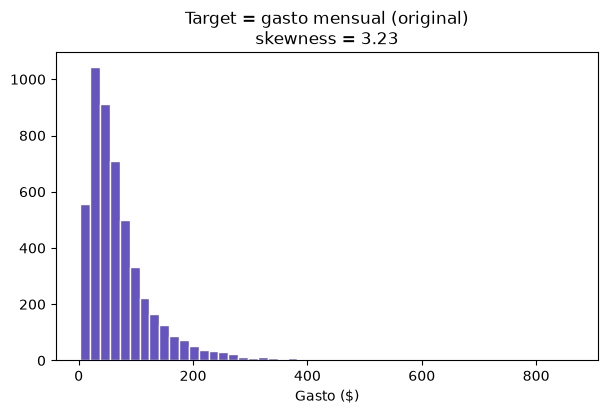

In [6]:
rng = np.random.default_rng(42)
gasto = rng.lognormal(mean=4, sigma=0.8, size=5000)

print(f"Mínimo:  ${gasto.min():.2f}")
print(f"Mediana: ${np.median(gasto):.2f}")
print(f"Media:   ${gasto.mean():.2f}")
print(f"Máximo:  ${gasto.max():.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
histograma(ax, gasto, "Target = gasto mensual (original)")
ax.set_xlabel("Gasto ($)")
plt.show()



### 1.2 Log: ln(y)

In [9]:
gasto_log = np.log(gasto)
print(f"Skewness de la target original: {fmt(skew(gasto))}")
print(f"Skewness de la target transformada con log: {fmt(skew(gasto_log))}")

Skewness de la target original: 3.23
Skewness de la target transformada con log: 0.00


### 1.3 Box-Cox

In [14]:
bc = PowerTransformer(method="box-cox", standardize=False) # standardize = false porque no es necesario para la target. Sí lo sería para features.

gasto_bc = bc.fit_transform(gasto.reshape(-1, 1)).ravel()

print(f"λ elegido: {fmt(bc.lambdas_[0])}") #lambdas_ es un array que devuelve el mejor lambda
print(f"Skewness de la target original: {fmt(skew(gasto))}")
print(f"Skewness de la target transformada con Box-Cox: {fmt(skew(gasto_bc))}")

λ elegido: 0.00
Skewness de la target original: 3.23
Skewness de la target transformada con Box-Cox: 0.00


Obs: λ dio cercano a 0, quiere decir que la transformación logarítmica común es la que produce la distribución más parecida a la normal.

### 1.4 Yeo-Johnson

In [13]:
yj = PowerTransformer(method="yeo-johnson", standardize=False)

gasto_yj = yj.fit_transform(gasto.reshape(-1, 1)).ravel() #reshape porque sklearn espera una matriz. Ravel para volver a un array de 1 dimensión.

print(f"λ elegido: {fmt(yj.lambdas_[0])}")
print(f"Skewness de la target original: {fmt(skew(gasto))}")
print(f"Skewness de la target transformada con Yeo-Johnson: {fmt(skew(gasto_yj))}")

λ elegido: -0.03
Skewness de la target original: 3.23
Skewness de la target transformada con Yeo-Johnson: 0.00


### 1.5 Comparación

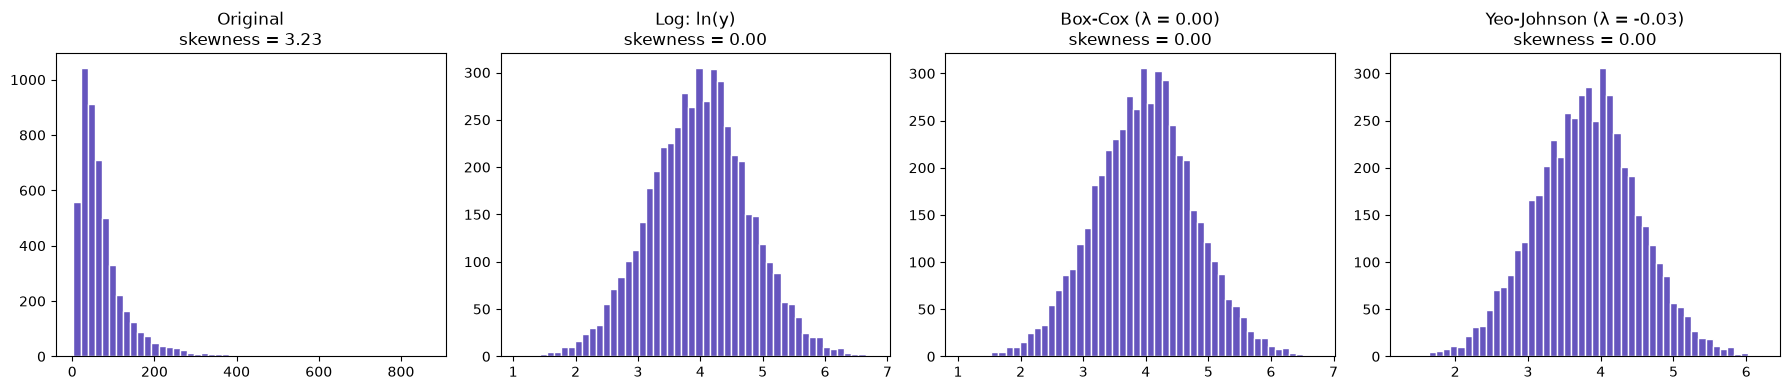

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
histograma(axes[0], gasto, "Original")
histograma(axes[1], gasto_log, "Log: ln(y)")
histograma(axes[2], gasto_bc, f"Box-Cox (λ = {fmt(bc.lambdas_[0])})")
histograma(axes[3], gasto_yj, f"Yeo-Johnson (λ = {fmt(yj.lambdas_[0])})")
plt.tight_layout()
plt.show()


---
## Caso 2: Asimetría negativa

### 2.1 Datos originales
Simulamos las notas (0 a 10) de 5.000 alumnos en un examen

Mínimo:  1.60
Media:   8.03
Mediana: 8.34
Máximo:  10.00


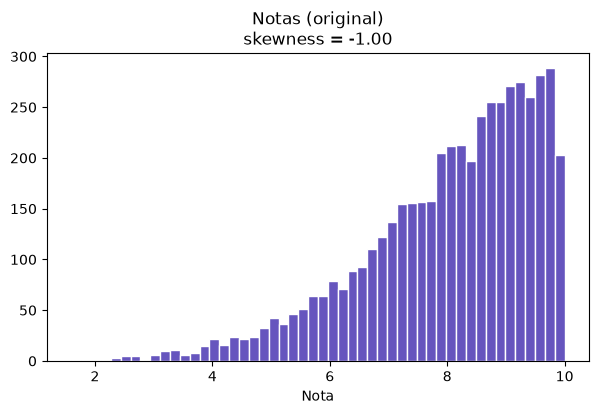

In [16]:
rng = np.random.default_rng(42)
notas = 10 * rng.beta(a=5, b=1.2, size=5000)

print(f"Mínimo:  {notas.min():.2f}")
print(f"Media:   {notas.mean():.2f}")
print(f"Mediana: {np.median(notas):.2f}")
print(f"Máximo:  {notas.max():.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
histograma(ax, notas, "Notas (original)")
ax.set_xlabel("Nota")
plt.show()

### 2.2 Log: ln(y)

In [17]:
notas_log = np.log(notas)
print(f"Skewness de la target original: {fmt(skew(notas))}")
print(f"Skewness de la target transformada con log: {fmt(skew(notas_log))}")

Skewness de la target original: -1.00
Skewness de la target transformada con log: -1.78


Obs: El log empeora la asimetría negativa, porque comprime los valores altos (donde está la mayoría) y estira los bajos (la cola).

### 2.3 Box-Cox

In [20]:
bc_n = PowerTransformer(method="box-cox", standardize=False)
notas_bc = bc_n.fit_transform(notas.reshape(-1, 1)).ravel()
print(f"λ elegido: {fmt(bc_n.lambdas_[0])}")
print(f"Skewness de la target original: {fmt(skew(notas))}")
print(f"Skewness de la target transformada con Box-Cox: {fmt(skew(notas_bc))}")

λ elegido: 2.91
Skewness de la target original: -1.00
Skewness de la target transformada con Box-Cox: -0.23


Obs: λ > 1, Box-Cox eligió una potencia que estira los valores altos.

### 2.5 Yeo-Johnson

In [21]:
yj_n = PowerTransformer(method="yeo-johnson", standardize=False)
notas_yj = yj_n.fit_transform(notas.reshape(-1, 1)).ravel()
print(f"λ elegido: {fmt(yj_n.lambdas_[0])}")
print(f"Skewness de la target original: {fmt(skew(notas))}")
print(f"Skewness de la target transformada con Yeo-Johnson: {fmt(skew(notas_yj))}")

λ elegido: 3.22
Skewness de la target original: -1.00
Skewness de la target transformada con Yeo-Johnson: -0.22


### 2.6 Comparación

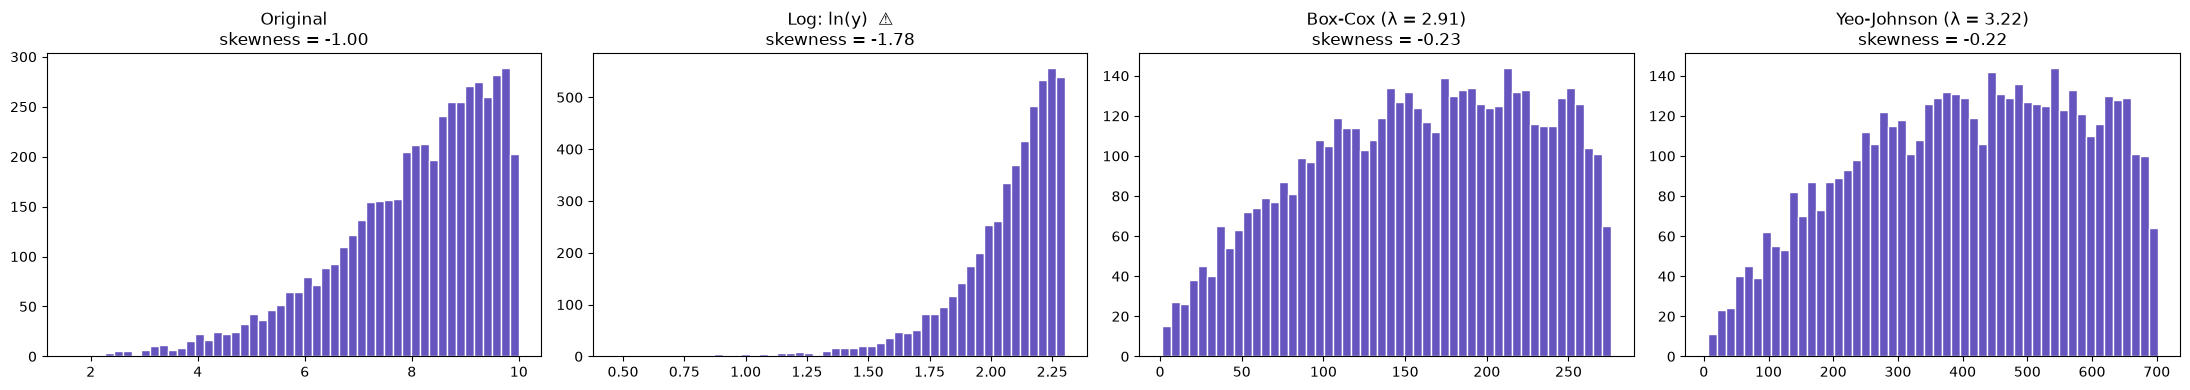

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
histograma(axes[0], notas, "Original")
histograma(axes[1], notas_log, "Log: ln(y)")
histograma(axes[2], notas_bc, f"Box-Cox (λ = {fmt(bc_n.lambdas_[0])})")
histograma(axes[3], notas_yj, f"Yeo-Johnson (λ = {fmt(yj_n.lambdas_[0])})")
plt.tight_layout()
plt.show()

Conclusiones:
- Para la asimetría positiva, todas las transformaciones funcionan.
- Para la asimetría negativa, la transformación logarítmica empeora la asimetría. En este caso conviene usar Box-Cox o Yeo-Johnson.
- Box-Cox y Yeo-Johnson eligen λ automáticamente: menor a 1 para asimetría positiva, mayor a 1 para negativa.